# Week 5 — Combining Models: Boosting, CART and Ensembles

**Syllabus topics:** Bayesian model averaging · boosting and adaptive basis function models · CART · generalized additive models · ensemble learning.

Every question below is self-contained: run any cell on its own. All questions use the Seattle daily weather data (`website/data/seattle_weather.csv`); models are trained on 2012–2014 and tested on 2015.

In [1]:
%config InlineBackend.figure_format = "svg"
import sys
sys.path.insert(0, "website")          # weather.py and the data live in website/
from weather import use_style
use_style()

## Theory — Bayesian model averaging

Instead of betting on one model, weight every candidate by how well it explains the data (its posterior probability, approximated here with BIC) and average their predictions. The task is tomorrow's temperature.

model                  posterior weight   test RMSE
today's high                    0.000       2.852
high + low                      0.000       2.808
high + low + wind               0.000       2.801
high + low + rain               0.000       2.781
high + low + season             0.857       2.695
everything                      0.143       2.680

Bayesian model average:                 2.690 °C


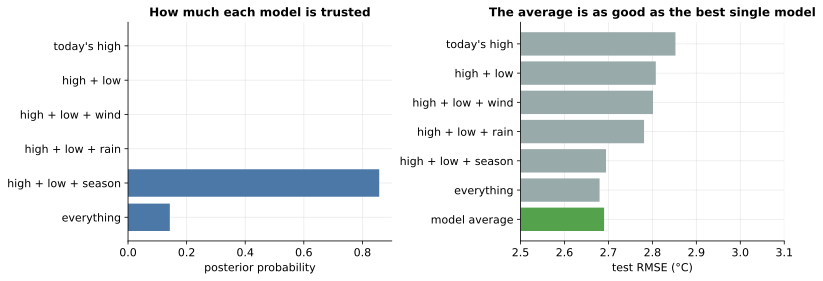

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from weather import load, split

train, test = split(load())
candidates = {
    "today's high": ["temp_max"],
    "high + low": ["temp_max", "temp_min"],
    "high + low + wind": ["temp_max", "temp_min", "wind"],
    "high + low + rain": ["temp_max", "temp_min", "precipitation"],
    "high + low + season": ["temp_max", "temp_min", "month_sin", "month_cos"],
    "everything": ["temp_max", "temp_min", "wind", "precipitation", "month_sin", "month_cos"],
}
design = lambda df, cols: np.c_[np.ones(len(df)), df[cols].values]
y, yt, n = train.temp_tomorrow.values, test.temp_tomorrow.values, len(train)

bic, preds = {}, {}
for name, cols in candidates.items():
    w = np.linalg.lstsq(design(train, cols), y, rcond=None)[0]
    rss = np.sum((y - design(train, cols) @ w) ** 2)
    bic[name] = n * np.log(rss / n) + (len(cols) + 1) * np.log(n)         # smaller BIC = better model
    preds[name] = design(test, cols) @ w
weights = np.exp(-0.5 * (np.array(list(bic.values())) - min(bic.values()))); weights /= weights.sum()   # posterior model probabilities
bma = sum(wi * preds[name] for wi, name in zip(weights, candidates))
rmse = lambda p: np.sqrt(np.mean((yt - p) ** 2))

print("model                  posterior weight   test RMSE")
for wi, name in zip(weights, candidates): print(f"{name:<22} {wi:>14.3f}   {rmse(preds[name]):>9.3f}")
print(f"\nBayesian model average:{'':>10}   {rmse(bma):>9.3f} °C")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].barh(list(candidates), weights, color="#4c78a8"); ax[0].invert_yaxis(); ax[0].set_xlabel("posterior probability"); ax[0].set_title("How much each model is trusted")
errors = {**{k: rmse(v) for k, v in preds.items()}, "model average": rmse(bma)}
ax[1].barh(list(errors), list(errors.values()), color=["#9aa"] * len(preds) + ["#54a24b"]); ax[1].invert_yaxis(); ax[1].set_xlim(2.5, 3.1)
ax[1].set_xlabel("test RMSE (°C)"); ax[1].set_title("The average is as good as the best single model")
plt.show()

## Theory — Boosting and adaptive basis function models

Boosting builds f(x) = Σ αₘ hₘ(x): a sum of simple "basis functions" (one-question trees), each added to fix the mistakes of the ones before. We write AdaBoost from scratch and compare with scikit-learn.

after 150 rounds: our AdaBoost test accuracy 0.709 | scikit-learn's AdaBoost 0.709 | 'tomorrow = today' 0.703
first round (a single question): test accuracy 0.703


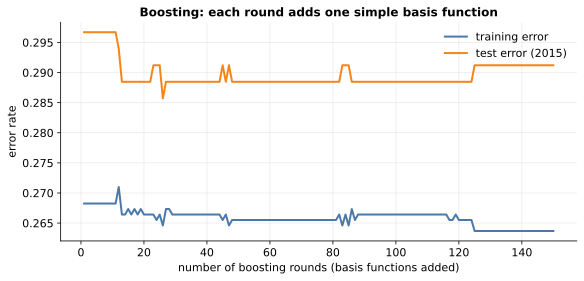

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from weather import load, split, FEATURES

train, test = split(load())
X, y = train[FEATURES].values, np.where(train.rain_tomorrow == 1, 1, -1)       # labels are -1 / +1
Xt, yt = test[FEATURES].values, np.where(test.rain_tomorrow == 1, 1, -1)

weights = np.full(len(y), 1 / len(y))                                          # every day starts equally important
score_tr, score_te = np.zeros(len(y)), np.zeros(len(yt))
err_tr, err_te = [], []
for m in range(150):
    stump = DecisionTreeClassifier(max_depth=1, random_state=0).fit(X, y, sample_weight=weights)   # one yes/no question
    miss = stump.predict(X) != y
    e = weights[miss].sum()
    alpha = 0.5 * np.log((1 - e) / max(e, 1e-12))                              # a better stump gets a bigger say
    weights *= np.exp(alpha * np.where(miss, 1, -1)); weights /= weights.sum() # wrongly predicted days become more important
    score_tr += alpha * stump.predict(X); score_te += alpha * stump.predict(Xt)
    err_tr.append(np.mean(np.sign(score_tr) != y)); err_te.append(np.mean(np.sign(score_te) != yt))

sk = AdaBoostClassifier(n_estimators=150, random_state=0).fit(X, y)
print(f"after 150 rounds: our AdaBoost test accuracy {1 - err_te[-1]:.3f} | scikit-learn's AdaBoost {sk.score(Xt, yt):.3f} | 'tomorrow = today' {np.mean(np.where(test.rain == 1, 1, -1) == yt):.3f}")
print(f"first round (a single question): test accuracy {1 - err_te[0]:.3f}")

plt.figure(figsize=(8, 3.8))
plt.plot(range(1, 151), err_tr, label="training error"); plt.plot(range(1, 151), err_te, label="test error (2015)")
plt.xlabel("number of boosting rounds (basis functions added)"); plt.ylabel("error rate"); plt.title("Boosting: each round adds one simple basis function"); plt.legend(); plt.show()

## Theory — Generalized additive models (GAM)

A GAM predicts with a sum of smooth curves, one per input: y = c + f₁(x₁) + f₂(x₂) + ... Each curve is a spline, so we can read what every input does on its own.

test RMSE: linear model 2.783 °C | additive model with splines 2.796 °C


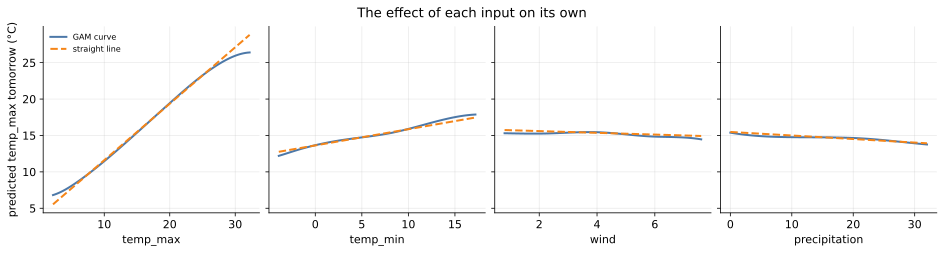

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import SplineTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from weather import load, split

train, test = split(load())
cols = ["temp_max", "temp_min", "wind", "precipitation"]
splines = ColumnTransformer([(c, SplineTransformer(n_knots=6, degree=3), [c]) for c in cols])      # a flexible curve per input
gam = make_pipeline(splines, Ridge(alpha=1.0)).fit(train[cols], train.temp_tomorrow)
linear = LinearRegression().fit(train[cols], train.temp_tomorrow)
rmse = lambda m: np.sqrt(np.mean((test.temp_tomorrow - m.predict(test[cols])) ** 2))
print(f"test RMSE: linear model {rmse(linear):.3f} °C | additive model with splines {rmse(gam):.3f} °C")

base = train[cols].median()
fig, ax = plt.subplots(1, 4, figsize=(13, 3.4), sharey=True)
for a, c in zip(ax, cols):
    grid = np.linspace(train[c].quantile(.01), train[c].quantile(.99), 100)
    frame = pd.DataFrame(np.tile(base.values, (100, 1)), columns=cols); frame[c] = grid       # vary one input, hold the others at their median
    a.plot(grid, gam.predict(frame), label="GAM curve"); a.plot(grid, linear.predict(frame), "--", label="straight line")
    a.set_xlabel(c)
ax[0].set_ylabel("predicted temp_max tomorrow (°C)"); ax[0].legend(fontsize=8); fig.suptitle("The effect of each input on its own"); plt.show()

## Practice 1 — Implement CART learning algorithm to perform categorization

CART grows a tree by repeatedly asking the yes/no question that makes the two groups purest, measured by Gini impurity. We write the whole algorithm from scratch, compare it with scikit-learn, then see how depth affects over-fitting.

if precipitation <= 0.30:
    if temp_max <= 18.90:
        if temp_min <= 1.10:
            -> no rain
        else:
            -> no rain
    else:
        if temp_max <= 25.60:
            -> no rain
        else:
            -> no rain
else:
    if month_cos <= -0.00:
        if precipitation <= 6.90:
            -> no rain
        else:
            -> RAIN
    else:
        if precipitation <= 2.00:
            -> RAIN
        else:
            -> RAIN

test accuracy: our CART 0.725 | scikit-learn 0.717 | 'tomorrow = today' 0.703
the two trees agree on 98% of the test days


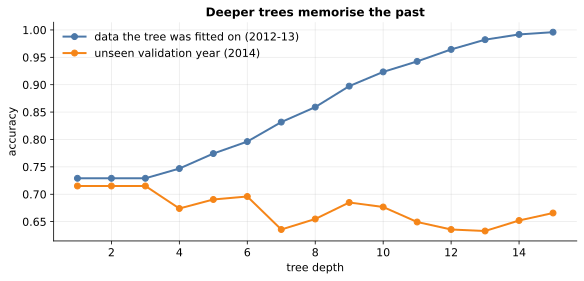

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from weather import load, split, FEATURES

train, test = split(load())
X, y = train[FEATURES].values, train.rain_tomorrow.values.astype(int)
Xt, yt = test[FEATURES].values, test.rain_tomorrow.values.astype(int)
gini = lambda y: 1 - y.mean() ** 2 - (1 - y.mean()) ** 2                       # 0 = pure group

def best_split(X, y):
    best = (np.inf, None, None)
    for j in range(X.shape[1]):
        for thr in np.unique(X[:, j])[:-1]:
            left = X[:, j] <= thr
            score = (left.sum() * gini(y[left]) + (~left).sum() * gini(y[~left])) / len(y)
            if score < best[0]: best = (score, j, thr)
    return best

def grow(X, y, depth, max_depth, min_leaf=20):
    if depth == max_depth or len(y) < 2 * min_leaf or gini(y) == 0: return int(y.mean() > .5)
    _, j, thr = best_split(X, y)
    left = X[:, j] <= thr
    if left.sum() < min_leaf or (~left).sum() < min_leaf: return int(y.mean() > .5)
    return (j, thr, grow(X[left], y[left], depth + 1, max_depth), grow(X[~left], y[~left], depth + 1, max_depth))

def predict_one(node, x):
    while isinstance(node, tuple): node = node[2] if x[node[0]] <= node[1] else node[3]
    return node

def show(node, indent=""):
    if not isinstance(node, tuple): print(indent + ("-> RAIN" if node else "-> no rain")); return
    print(f"{indent}if {FEATURES[node[0]]} <= {node[1]:.2f}:"); show(node[2], indent + "    ")
    print(f"{indent}else:"); show(node[3], indent + "    ")

tree = grow(X, y, 0, 3)
show(tree)
ours = np.array([predict_one(tree, x) for x in Xt])
sk = DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, random_state=0).fit(X, y)
print(f"\ntest accuracy: our CART {np.mean(ours == yt):.3f} | scikit-learn {sk.score(Xt, yt):.3f} | 'tomorrow = today' {np.mean(test.rain.values == yt):.3f}")
print(f"the two trees agree on {np.mean(ours == sk.predict(Xt)):.0%} of the test days")

fit_part, val_part = train[train.date < "2014-01-01"], train[train.date >= "2014-01-01"]      # choose depth on 2014, not on the test year
depths = range(1, 16)
fit_acc, val_acc = [], []
for dep in depths:
    t = DecisionTreeClassifier(max_depth=dep, random_state=0).fit(fit_part[FEATURES], fit_part.rain_tomorrow)
    fit_acc.append(t.score(fit_part[FEATURES], fit_part.rain_tomorrow)); val_acc.append(t.score(val_part[FEATURES], val_part.rain_tomorrow))
plt.figure(figsize=(8, 3.8))
plt.plot(depths, fit_acc, "o-", label="data the tree was fitted on (2012-13)"); plt.plot(depths, val_acc, "o-", label="unseen validation year (2014)")
plt.xlabel("tree depth"); plt.ylabel("accuracy"); plt.title("Deeper trees memorise the past"); plt.legend(); plt.show()

## Practice 2 — Implement ensemble learning models to perform classification

An ensemble combines many models. Bagging averages trees trained on random re-samples; a random forest adds random feature choice; boosting adds trees one after another; voting and stacking combine different kinds of model. All are compared with plain logistic regression.

'tomorrow = today' accuracy: 0.703   (with 364 test days, one accuracy is uncertain by about ±2.4 points)

                                 accuracy  log-loss
voting (lr + forest + boosting)     0.728     0.541
logistic regression                 0.728     0.559
random forest                       0.717     0.547
stacking                            0.712     0.552
bagging (our code, 100 trees)       0.709     0.579
gradient boosting                   0.709     0.548
one deep tree                       0.687     0.702


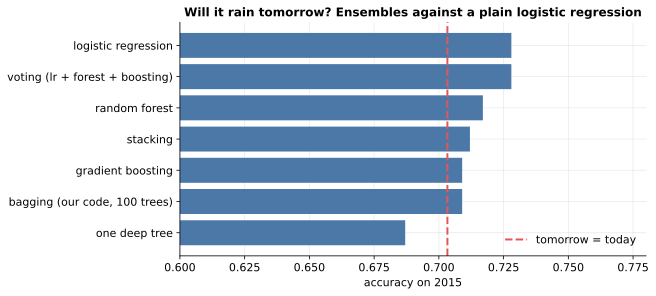

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from weather import load, split, FEATURES

train, test = split(load())
X, y = train[FEATURES].values, train.rain_tomorrow.values.astype(int)
Xt, yt = test[FEATURES].values, test.rain_tomorrow.values.astype(int)
baseline = np.mean(test.rain.values == yt)

# Bagging from scratch: 100 deep trees, each trained on a random re-sample of the days, then a vote
rng = np.random.default_rng(0)
votes = np.zeros((len(Xt), 100))
for i in range(100):
    pick = rng.integers(0, len(X), len(X))
    votes[:, i] = DecisionTreeClassifier(min_samples_leaf=10, random_state=i).fit(X[pick], y[pick]).predict(Xt)
bag_prob = votes.mean(1)

rf = RandomForestClassifier(150, min_samples_leaf=5, random_state=0)
gb = GradientBoostingClassifier(n_estimators=100, max_depth=2, learning_rate=.05, random_state=0)
lr = LogisticRegression(max_iter=1000)
models = {
    "one deep tree": DecisionTreeClassifier(min_samples_leaf=10, random_state=0),
    "random forest": rf, "gradient boosting": gb,
    "voting (lr + forest + boosting)": VotingClassifier([("lr", lr), ("rf", rf), ("gb", gb)], voting="soft"),
    "stacking": StackingClassifier([("rf", rf), ("gb", gb)], final_estimator=lr, cv=5),
    "logistic regression": lr,
}
rows = {"bagging (our code, 100 trees)": (np.mean((bag_prob > .5) == yt), log_loss(yt, np.clip(bag_prob, .02, .98)))}
for name, m in models.items():
    p = m.fit(X, y).predict_proba(Xt)[:, 1]
    rows[name] = (np.mean((p > .5) == yt), log_loss(yt, np.clip(p, .02, .98)))
table = pd.DataFrame(rows, index=["accuracy", "log-loss"]).T.sort_values("accuracy", ascending=False).round(3)
print(f"'tomorrow = today' accuracy: {baseline:.3f}   (with {len(yt)} test days, one accuracy is uncertain by about ±{100 * np.sqrt(.7 * .3 / len(yt)):.1f} points)\n")
print(table)

fig, ax = plt.subplots(figsize=(9, 4))
ordered = table.accuracy.sort_values()
ax.barh(ordered.index, ordered.values, color="#4c78a8")
ax.axvline(baseline, color="#e45756", ls="--", label="tomorrow = today"); ax.set_xlim(.6, .78)
ax.set_xlabel("accuracy on 2015"); ax.set_title("Will it rain tomorrow? Ensembles against a plain logistic regression"); ax.legend(loc="lower right"); plt.show()